In [1]:
import pandas as pd
import numpy as np

In [4]:
s = pd.Series([1,2,3], index=["a","b","c"])
print(s)

print( s['a'])
print( s['b'])

a    1
b    2
c    3
dtype: int64
1
2


In [6]:
index_val = [('a',2019), ('b',2020)]
s = pd.Series([1,2], index=index_val)

s['a']  # index_val = [('a',2019), ('b',2020)]

KeyError: 'a'

In [ ]:
# to solve above # creat Multi INdex from Tuples 
# pd.MultiIndex.from_tuples(tuples)

tuples = [ ('nov', 2020), ('nov', 2021), ('jan', 2002), ("jan", 2001)]
mul_index = pd.MultiIndex.from_tuples(tuples)

s = pd.Series([1,2,3,4], index = mul_index)

print(s)
print()
print( s["nov"])
print()
print( s["jan"] )
print(s[('jan', 2001)])
# now two levels of indexes are made level 0 and level 1
# Level 1 → jan 
# Level 2 → 2019

tuples = [('math',1), ('math',2), ('cs',1), ('cs',2)]
s = pd.Series([10,20,30,40], index=pd.MultiIndex.from_tuples(tuples))



nov  2020    1
     2021    2
jan  2002    3
     2001    4
dtype: int64

2020    1
2021    2
dtype: int64

2002    3
2001    4
dtype: int64
4


the above :

they are now is hiercal because there is one uppr level and and one lower level index

Folder → Subfolder → File

- nov/
   - 2019 → 1
   - 2020 → 2
- jan/
   - 2019 → 3
   - 2020 → 4

In [19]:
# another way to form Multi index is using from_product
# pd.MultiIndex.from_product([A, B])

idx = pd.MultiIndex.from_product( [
    ['cse', 'ece'],
    [2020,2022,2028]
])

s = pd.Series(range(1,7), index=idx)

s

cse  2020    1
     2022    2
     2028    3
ece  2020    4
     2022    5
     2028    6
dtype: int64

the above 

        pd.MultiIndex.from_product([A, B])

> Cartesian product (ALL combinations)

['cse','ece'] × [2019,2020,2021]

becomes

- (cse,2019)
- (cse,2020)
- (cse,2021)
- (ece,2019)
- (ece,2020)
- (ece,2021)



# stack vs Unstack

unstack() = convert inner index to columns

stack() = convert columns → index

In [22]:
index = pd.MultiIndex.from_product([
    ['A', 'B'],
    [1,2]
])

s = pd.Series([1,2,3,4], index = index)
s

A  1    1
   2    2
B  1    3
   2    4
dtype: int64

In [ ]:
df = s.unstack()
df # inner index becomes cols

,1,2
A,1,2
B,3,4


In [ ]:
df.stack() #  col becomes inner index

A  1    1
   2    2
B  1    3
   2    4
dtype: int64

In [26]:
index = pd.MultiIndex.from_product([
    ['A','B'],
    [1,2,3]
])

s = pd.Series(range(6), index=index)

print(s)
print()

df = s.unstack()
df

A  1    0
   2    1
   3    2
B  1    3
   2    4
   3    5
dtype: int64



,1,2,3
A,0,1,2
B,3,4,5


# Data Frames

In [30]:


index = pd.MultiIndex.from_product([
    ['cse','ece'],
    [2019,2020]
])

df = pd.DataFrame({
    'students': [100,120,80,90],
    'avg_package': [10,12,8,9]
}, index=index)

print(df)
print()
print (df.loc["cse"] )
print()
df.loc["ece"]

          students  avg_package
cse 2019       100           10
    2020       120           12
ece 2019        80            8
    2020        90            9

      students  avg_package
2019       100           10
2020       120           12



,students,avg_package
2019,80,8
2020,90,9


In [31]:
# multi index on columns 
cols = pd.MultiIndex.from_product([
    ["Hokage", "Akatsuki"],
    ["Missions", "Income"]
])

df2 = pd.DataFrame([
    [100,10,90,29],
    [120,34,90,22]
], index=[2020, 2021], columns=cols)

df2

Hokage        Akatsuki       
     Missions Income Missions Income
2020      100     10       90     29
2021      120     34       90     22

In [ ]:
df2["Hokage"]

,Missions,Income
2020,100,10
2021,120,34


In [33]:
df2["Hokage"]["Missions"]

2020    100
2021    120
Name: Missions, dtype: int64

In [35]:
df3 = pd.DataFrame(
    [
        [100,10,90,9],
        [120,12,95,10],
        [80,8,70,7],
        [90,9,75,8]
    ],
    index=pd.MultiIndex.from_product([['cse','ece'],[2019,2020]]),
    columns=pd.MultiIndex.from_product([['delhi','mumbai'],['students','avg_package']])
)

df3

delhi               mumbai            
         students avg_package students avg_package
cse 2019      100          10       90           9
    2020      120          12       95          10
ece 2019       80           8       70           7
    2020       90           9       75           8

In [37]:
df3.loc[('cse',2019)]

delhi   students       100
        avg_package     10
mumbai  students        90
        avg_package      9
Name: (cse, 2019), dtype: int64

# Pivot Table #

```python
df.pivot_table(
    index='sex',
    columns='smoker',
    values='total_bill',
    aggfunc='sum'
)
```



In [38]:

import seaborn as sns

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.pivot_table(index='sex', values='total_bill')  #Average bill per gender
# equalent
# df.groupby('sex')['total_bill'].mean()

,total_bill
sex,
Male,20.744076
Female,18.056897


In [40]:
df.pivot_table(
    index='sex',
    columns='smoker',
    values='total_bill',
    aggfunc=['mean','max']
)

mean               max       
smoker        Yes         No    Yes     No
sex                                       
Male    22.284500  19.791237  50.81  48.33
Female  17.977879  18.105185  44.30  35.83

# Long vs Wide 

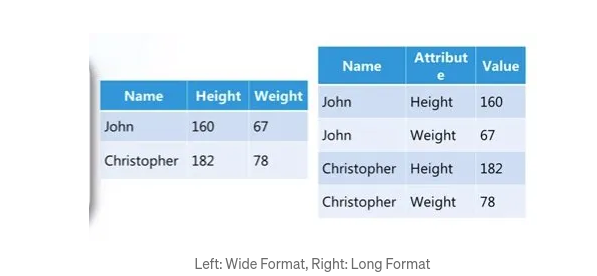

- Wide: More no of cols less Rows
- long: Less cols more rows

## Wide 

- Each variable has its own column.
- Each row usually represents one entity.

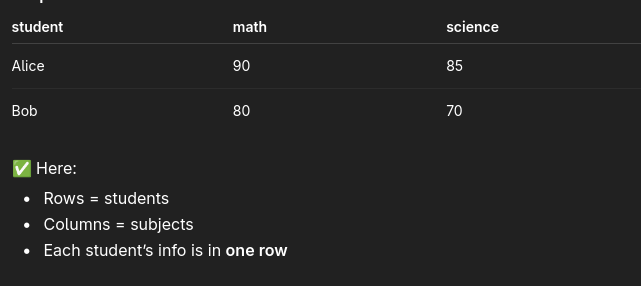

## Long 

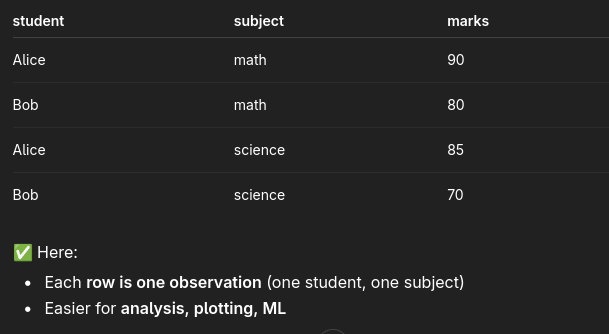


## melt 
- convert Wide to Long 

## Pivot
- Long to wide

In [43]:
df_wide = pd.DataFrame({
    'name': ['A', 'B', 'C'],
    'math': [90, 80, 70],
    'science': [85, 70, 60],
    'english': [95, 88, 76]
})

df_wide

,name,math,science,english
0,A,90,85,95
1,B,80,70,88
2,C,70,60,76


In [ ]:
# Long Format
df_long = pd.DataFrame({
    'name': ['A','A','A','B','B','B','C','C','C'],
    'subject': ['math','science','english','math','science','english','math','science','english'],
    'marks': [90,85,95,80,70,88,70,60,76]
})

df_long
# Notice how one student (A) has three rows now, one for each subject.

,name,subject,marks
0,A,math,90
1,A,science,85
2,A,english,95
3,B,math,80
4,B,science,70
5,B,english,88
6,C,math,70
7,C,science,60
8,C,english,76


In [47]:


df_wide = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie'],
    'math': [90, 80, 70],
    'science': [85, 75, 65],
    'english': [95, 85, 75]
})

df_wide

,name,math,science,english
0,Alice,90,85,95
1,Bob,80,75,85
2,Charlie,70,65,75


# pivot to convert

    df_wide.melt(
        id_vars=['name'], 
        var_name='subject', 
        value_name='marks'
    )

- id_vars=['name'] → columns to keep as identifier (stay in rows)
- var_name='subject' → new column for previous column names. (now except for "name" all other cols will go under this new Col)
- value_name='marks' → values from wide columns go here.

In [49]:
df_long = df_wide.melt( id_vars=["name"], var_name="Subjects", value_name="marks")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [50]:
df_wide2 = pd.DataFrame({
    'branch': ['CSE', 'ECE', 'MECH'],
    '2020': [100, 80, 60],
    '2021': [120, 90, 70],
    '2022': [150, 100, 80]
})
df_wide2

,branch,2020,2021,2022
0,CSE,100,120,150
1,ECE,80,90,100
2,MECH,60,70,80


In [52]:
df_long2 = df_wide2.melt( id_vars=["branch"], var_name="Year", value_name="Students")
df_long2

,branch,Year,Students
0,CSE,2020,100
1,ECE,2020,80
2,MECH,2020,60
3,CSE,2021,120
4,ECE,2021,90
5,MECH,2021,70
6,CSE,2022,150
7,ECE,2022,100
8,MECH,2022,80


In [53]:
df_wide3 = pd.DataFrame({
    'country': ['USA', 'India', 'China'],
    '2019': [328, 1366, 1393],
    '2020': [331, 1380, 1402],
    '2021': [334, 1393, 1411]
})
df_wide3

,country,2019,2020,2021
0,USA,328,331,334
1,India,1366,1380,1393
2,China,1393,1402,1411


In [54]:
df_long3 = df_wide3.melt(id_vars=["country"], var_name="Year", value_name="Population")
df_long3

,country,Year,Population
0,USA,2019,328
1,India,2019,1366
2,China,2019,1393
3,USA,2020,331
4,India,2020,1380
5,China,2020,1402
6,USA,2021,334
7,India,2021,1393
8,China,2021,1411


In [3]:
df_wide3 = pd.DataFrame({
    'country': ['USA', 'India', 'China'],
    '2019': [328, 1366, 1393],
    '2020': [331, 1380, 1402],
    '2021': [334, 1393, 1411]
})
df_wide3

,country,2019,2020,2021
0,USA,328,331,334
1,India,1366,1380,1393
2,China,1393,1402,1411


In [4]:
df_long4 = df_wide3.melt(id_vars=["country"],var_name="Year", value_name="Population")
df_long4

,country,Year,Population
0,USA,2019,328
1,India,2019,1366
2,China,2019,1393
3,USA,2020,331
4,India,2020,1380
5,China,2020,1402
6,USA,2021,334
7,India,2021,1393
8,China,2021,1411


In [5]:
import pandas as pd

df_wide5 = pd.DataFrame({
    'student': ['Alice', 'Bob'],
    'class': ['A', 'B'],
    'math_2020': [90, 80],
    'science_2020': [85, 75],
    'math_2021': [95, 85],
    'science_2021': [88, 78]
})

df_wide5

,student,class,math_2020,science_2020,math_2021,science_2021
0,Alice,A,90,85,95,88
1,Bob,B,80,75,85,78


In [7]:
df_long5 = df_wide5.melt(id_vars=['student', 'class'], var_name="subject_year", value_name="marks")
df_long5

,student,class,subject_year,marks
0,Alice,A,math_2020,90
1,Bob,B,math_2020,80
2,Alice,A,science_2020,85
3,Bob,B,science_2020,75
4,Alice,A,math_2021,95
5,Bob,B,math_2021,85
6,Alice,A,science_2021,88
7,Bob,B,science_2021,78


In [8]:


df_sales = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'North': [100, 150, 200],
    'South': [90, 120, 160],
    'East': [80, 110, 140],
    'West': [70, 100, 130]
})
df_sales

,product,North,South,East,West
0,A,100,90,80,70
1,B,150,120,110,100
2,C,200,160,140,130


In [10]:
df_sales_long = df_sales.melt(id_vars=["product"], var_name="region", value_name="sales")
df_sales_long

,product,region,sales
0,A,North,100
1,B,North,150
2,C,North,200
3,A,South,90
4,B,South,120
5,C,South,160
6,A,East,80
7,B,East,110
8,C,East,140
9,A,West,70


# pivot
wide to Long

In [11]:


df_marks = pd.DataFrame({
    'student': ['Alice', 'Alice', 'Bob', 'Bob'],
    'subject': ['Math', 'English', 'Math', 'English'],
    'marks': [90, 85, 78, 82]
})

print(df_marks)

  student  subject  marks
0   Alice     Math     90
1   Alice  English     85
2     Bob     Math     78
3     Bob  English     82


In [12]:
df_wide = df_marks.pivot(index="student", columns="subject", values="marks")
df_wide

subject,English,Math
student,,
Alice,85,90
Bob,82,78


In [13]:
df_sales = pd.DataFrame({
    'date': ['2026-01-01', '2026-01-01', '2026-01-02', '2026-01-02'],
    'store': ['S1', 'S2', 'S1', 'S2'],
    'sales': [200, 150, 220, 170]
})
df_sales

,date,store,sales
0,2026-01-01,S1,200
1,2026-01-01,S2,150
2,2026-01-02,S1,220
3,2026-01-02,S2,170


In [14]:
df_sales_wide = df_sales.pivot(index='date', columns='store', values='sales')
df_sales_wide

store,S1,S2
date,,
2026-01-01,200,150
2026-01-02,220,170
